# ONNX Policy Demo

## The problem

A lightly damped oscillator, released from rest at $x = 1$, swings around zero for a
long time before it settles:

$$\ddot{x} = -4x - 0.1\,\dot{x} + a$$

| term | meaning |
|---|---|
| $x$ | position, the quantity to be driven to zero |
| $-4x$ | restoring force, giving a natural frequency of $2$ rad/s |
| $-0.1\,\dot{x}$ | the oscillator's own damping, small, which is why it rings for so long |
| $a$ | the action, bounded to $[-1, 1]$ |

$a$ is where the policy enters. Every $0.1$ time units the current state
$(x, \dot{x})$ is handed to the network, which returns one value of $a$, and that
value is held constant while the solver advances the next ten steps. Nothing
consults Python in between. This is the same handoff a CFD case makes, where $a$
would be a jet flow rate written onto a boundary patch.

Each decision is then scored:

$$r = -x^{2} - 0.05\,a^{2}$$

The first term is the objective. It is largest at $x = 0$ and penalizes displacement to either side. The second term prices the action, so a policy that slams the action against its bounds to shave off a little displacement scores worse than one doing the same job gently. The weight $0.05$ sets the exchange rate between the two, and it is small because settling quickly matters more here than saving effort.

## What this notebook does

Exports a policy to ONNX, shows exactly how that file is loaded and evaluated
inside a simulation, trains it, and compares before and after.

The oscillator stands in for the CFD case and the controller stands in for the
OpenFOAM boundary condition. The oscillator is not a flow; its only job is to
respond to the action.

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2

In [ ]:
import re
import sys
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import uqtopus as uqt
import uqtopus.rl as rl
from uqtopus.rl.algos import PPO

root = Path("experiments/rl_onnx_demo")

## 1. Policy Spec

Declares what the policy sees, what it drives, and how often it acts.

In [ ]:
spec = rl.PolicySpec(
    observation=rl.ObservationSpec(
        sources=(rl.ProbeSource(field_name="p", positions=[(0.5, 0.0, 0.005), (1.0, 0.0, 0.005)]),)
    ),
    action=rl.ActionSpec(
        name="Q",
        targets={"jet1": 1.0, "jet2": -1.0},
        low=-1.0,
        high=1.0,
        distribution="gaussian",
    ),
    control_interval=0.1,
)
spec

PolicySpec(obs_dim=2, act_dim=1, dist='gaussian', dt=0.1, hash=15f22c63b454abf1)

## 2. Export to ONNX

The graph carries the network, the observation normalization and the output transforms. The spec is stamped into the file metadata, so the file describes itself.

In [ ]:
untrained = rl.export_random_policy(spec, root / "policy_untrained.onnx", seed=0)
untrained

PolicyArtifact(path='policy_untrained.onnx', iter=None, spec_hash=15f22c63b454abf1, opset=17)

In [ ]:
metadata = rl.read_metadata(untrained.path)
for key in ("obs_dim", "act_dim", "distribution", "action_low", "action_high", "spec_hash"):
    print(f"{key:<14} {metadata['uqtopus.' + key]}")

obs_dim        2
act_dim        1
distribution   gaussian
action_low     -1.0
action_high    1.0
spec_hash      15f22c63b454abf1


In [ ]:
print(rl.validate_policy(untrained, spec, strict=False))

Policy validation: experiments/rl_onnx_demo/policy_untrained.onnx
Status: OK

[PASS] file: valid ONNX model, 21001 bytes
[PASS] metadata: spec_hash=15f22c63b454abf1
[PASS] contract: 15f22c63b454abf1
[PASS] signature.input: float32 (batch, 2)
[PASS] signature.output: mean, log_std
[PASS] runtime: batch of 32 evaluated
[PASS] outputs: mean in [-0.531, 0.538], log_std in [-0.336, 0.112]
[WARN] parity: no reference supplied; the export was not checked against the source network


## 3. What the file returns

One forward pass. The graph takes a batch of observations and returns the parameters of a distribution over actions, not an action.

In [ ]:
session = ort.InferenceSession(str(untrained.path), providers=["CPUExecutionProvider"])

print("input  ", [(i.name, i.type, i.shape) for i in session.get_inputs()])
print("outputs", [(o.name, o.shape) for o in session.get_outputs()])

observation = np.array([[1.0, 0.0]], dtype=np.float32)      # x = 1, x' = 0
mean, log_std = session.run(None, {"observation": observation})

print(f"\nmean  {mean[0][0]:+.4f}")
print(f"std   {np.exp(log_std[0][0]):.4f}")

input   [('observation', 'tensor(float)', ['batch', 2])]
outputs [('mean', ['batch', 1]), ('log_std', ['batch', 1])]

mean  -0.0368
std   0.9325


## 4. How the network enters the simulation

This is the part that has to be replicated in OpenFOAM. Everything the compiled boundary condition has to do is in the class below, in the order it has to do it.

| here | in OpenFOAM |
|---|---|
| `__init__` | the boundary condition constructor, once per run |
| `act()` | `updateCoeffs()`, guarded so that it fires once per time step |
| `rng.normal` | sample on the master rank only, then broadcast |
| `np.clip` | clip to the bounds read from the ONNX metadata |
| the returned action | the value written onto the patch, ramped from the previous one |

Two of those guards fail silently if they are missed. OpenFOAM re-evaluates a boundary condition at every corrector loop of the pressure-velocity coupling, so an unguarded stochastic policy draws a different action several times within one time step. And under domain decomposition each rank would draw its own. Neither raises an error; both train on actions that were never applied.

In [ ]:
class OnnxController:
    """The policy, loaded from a file and evaluated inside the simulation."""

    def __init__(self, policy_path, seed=0):
        # Load the graph ONCE. In C++ this belongs in the constructor, never in
        # updateCoeffs(): rebuilding the session every time step is ruinous.
        self.session = ort.InferenceSession(
            str(policy_path), providers=["CPUExecutionProvider"]
        )

        # Bounds and dimensions come from the file itself, so the case and the
        # policy cannot disagree about them.
        metadata = rl.read_metadata(policy_path)
        self.obs_dim = int(metadata["uqtopus.obs_dim"])
        self.low = np.array([float(v) for v in metadata["uqtopus.action_low"].split()])
        self.high = np.array([float(v) for v in metadata["uqtopus.action_high"].split()])

        self.rng = np.random.default_rng(seed)
        self.previous = np.zeros(len(self.low))

    def act(self, observation, deterministic=False):
        """One control step. In C++, once per time step, not per corrector loop."""
        # float32, shape (1, obs_dim). The graph's batch axis is dynamic, so the
        # solver passes a batch of one. In C++ this is an Ort::Value built over a
        # float buffer with shape {1, obs_dim}.
        x = np.asarray(observation, dtype=np.float32).reshape(1, self.obs_dim)

        # The forward pass, and nothing else: the observation normalization and
        # the output transforms are already inside the graph.
        mean, log_std = self.session.run(None, {"observation": x})

        # Sampling is the only thing left outside the graph. In parallel only the
        # master rank draws and the result is broadcast, otherwise each rank
        # applies a different value on its slice of the patch.
        if deterministic:
            action = mean[0]
        else:
            action = self.rng.normal(mean[0], np.exp(log_std[0]))

        action = np.clip(action, self.low, self.high)

        # Kept because the solver ramps linearly from the previous action
        # to this one over the first rampFraction of the control interval,
        # so that a boundary value never jumps.
        self.previous = action
        return action

## 5. The simulation around it

Everything outside the controller is what OpenFOAM already provides: advance the state, and at each control step ask the controller for an action and log what happened.

In [ ]:
class MockSimulation:
    def __init__(self, policy_path, spec, n_steps=60, dt=0.01, substeps=10):
        self.policy_path = policy_path
        self.spec = spec
        self.n_steps = n_steps
        self.dt = dt
        self.substeps = substeps

    def run(self, case_dir, seed=0, deterministic=False):
        controller = OnnxController(self.policy_path, seed=seed)
        x, v, t = 1.0, 0.0, 0.0
        times, observations, actions = [], [], []
        cfd_log = []                                  # one row per CFD time step

        for k in range(self.n_steps):
            obs = np.array([x, v])
            a = float(controller.act(obs, deterministic=deterministic)[0])

            for _ in range(self.substeps):            # the CFD time steps
                v += (-4.0 * x - 0.1 * v + a) * self.dt
                x += v * self.dt
                t += self.dt
                cfd_log.append((t, 0.5 * v**2 + 2.0 * x**2))   # energy, a solver diagnostic

            times.append(self.spec.control_interval * (k + 1))
            observations.append(obs)                  # as fed to the network
            actions.append([a])                       # as applied

        # what a functionObject writes: its own directory, its own resolution
        energy = Path(case_dir) / "postProcessing/energy/0/energy.dat"
        energy.parent.mkdir(parents=True, exist_ok=True)
        energy.write_text(
            "\n".join(["# Oscillator energy", "# Time\tE"]
                       + [f"{t:.6g}\t{e:.6g}" for t, e in cfd_log]) + "\n"
        )

        path = rl.write_trajectory(
            Path(case_dir) / "postProcessing/uqtopusPolicy/0/trajectory.dat",
            self.spec, times, np.array(observations), np.array(actions), seed=seed,
        )
        return rl.read_trajectory(path, self.spec)

## 6. Running with the untrained policy

The ONNX file is the only thing handed over. What comes back is the trajectory.

In [ ]:
before = MockSimulation(untrained.path, spec).run(root / "run_untrained", seed=42)
before

<xarray.Dataset> Size: 2kB
Dimensions:        (time: 60, obs_component: 2, act_component: 1)
Coordinates:
  * time           (time) float64 480B 0.1 0.2 0.3 0.4 0.5 ... 5.7 5.8 5.9 6.0
  * obs_component  (obs_component) <U10 80B 'probes.p.0' 'probes.p.1'
  * act_component  (act_component) <U1 4B 'Q'
Data variables:
    observation    (time, obs_component) float64 960B 1.0 0.0 ... 0.3595 0.4994
    action         (time, act_component) float64 480B 0.2474 -1.0 ... 0.7551
Attributes:
    spec_hash:  15f22c63b454abf1
    seed:       42
    source:     experiments/rl_onnx_demo/run_untrained/postProcessing/uqtopus...
    n_steps:    60

The spec hash travels inside the trajectory file. A policy, a case dictionary and a
parser that disagree are caught on read, rather than after a run that has already
been paid for.

In [ ]:
wrong = rl.PolicySpec(
    observation=spec.observation,
    action=spec.action,
    control_interval=0.2,      # someone edited the case dictionary
)

try:
    rl.read_trajectory(root / "run_untrained", wrong)
except rl.TrajectoryError as exc:
    print(exc)

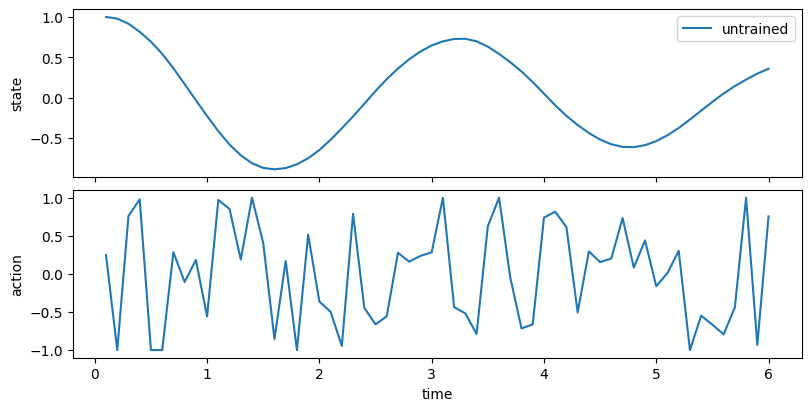

In [ ]:
def plot_run(datasets, labels):
    fig, axs = plt.subplots(2, 1, figsize=(8, 4), sharex=True, constrained_layout=True)
    for ds, label in zip(datasets, labels):
        axs[0].plot(ds["time"].values, ds["observation"].values[:, 0], label=label)
        axs[1].plot(ds["time"].values, ds["action"].values[:, 0], label=label)
    axs[0].set_ylabel("state")
    axs[1].set_ylabel("action")
    axs[1].set_xlabel("time")
    axs[0].legend()
    plt.show()


plot_run([before], ["untrained"])

## 7. Training

The runner exports a policy, launches the cases and reads the trajectories back. `run_fn` decides how a case is executed: here the mock, in production the solver.

In [ ]:
template = root / "template"
(template / "0").mkdir(parents=True, exist_ok=True)
(template / "0" / "U").write_text("jet1\n{\n{{ controller }}\n}\n")
(template / "Allrun").write_text("#!/bin/sh\n")


def run_fn(case_dir, params):
    """Reads the policy path and the seed out of the rendered case dictionary."""
    block = next(v for k, v in params.items() if "controller" in k)
    policy_path = re.search(r'policy\s+"([^"]+)"', block).group(1)
    seed = int(re.search(r"^\s*seed\s+(-?\d+);", block, re.M).group(1))
    MockSimulation(policy_path, spec).run(case_dir, seed=seed)


def reward_fn(ds):
    state = ds["observation"].values[:, 0]
    action = ds["action"].values[:, 0]
    return -(state**2) - 0.05 * action**2


runner = rl.ClosedLoopRunner(
    simulator=uqt.OpenFOAMSimulator(template, "Allrun", root / "runs", ["p"]),
    spec=spec,
    reward_fn=reward_fn,
    controller_keys="0__U__controller",
    run_fn=run_fn,
)
runner

ClosedLoopRunner(obs_dim=2, act_dim=1, spec_hash=15f22c63b454abf1)

In [ ]:
model = PPO(
    "MlpPolicy", runner,
    n_episodes=4, export_dir=root / "policies",
    batch_size=60, n_epochs=10, seed=0,
)
model.learn(total_timesteps=12 * 4 * 60)

trained = model.export_current_policy(root / "policy_trained.onnx")

print("mean return per iteration:")
print(np.round(model.returns_history, 1))

mean return per iteration:
[-25.6 -25.2 -20.9 -16.8 -15.1 -11.4 -10.3  -8.8  -8.3  -8.4  -8.7  -8.5]


## 8. The policy, before and after

Sweeping the state through the graph shows what training changed. The second observation component is held at zero, so this is a slice through the policy, not all of it.

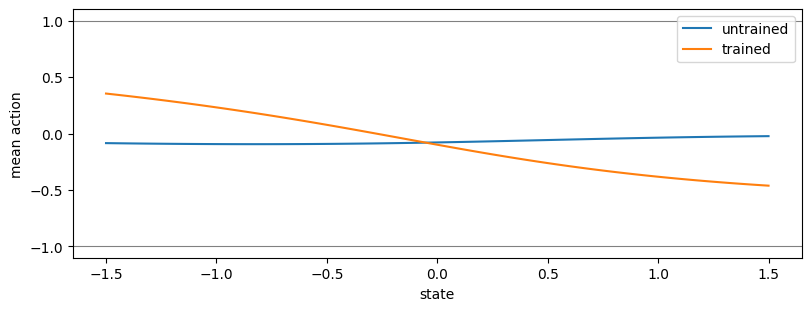

In [ ]:
def policy_mean(policy_path, x, v=0.0):
    session = ort.InferenceSession(str(policy_path), providers=["CPUExecutionProvider"])
    obs = np.column_stack([x, np.full_like(x, v)]).astype(np.float32)
    mean, _ = session.run(None, {"observation": obs})
    return mean[:, 0]


x = np.linspace(-1.5, 1.5, 101)

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.plot(x, policy_mean(untrained.path, x), label="untrained")
ax.plot(x, policy_mean(trained.path, x), label="trained")
ax.axhline(spec.action.low[0], color="gray", lw=0.8)
ax.axhline(spec.action.high[0], color="gray", lw=0.8)
ax.set_xlabel("state")
ax.set_ylabel("mean action")
ax.legend()
plt.show()

The trained mean leaves the action bounds, drawn as the gray lines. A Gaussian mean is unbounded and the controller clips, so nothing penalizes the network for pushing past the limit. It works, but it is the reason a Beta distribution is worth considering for bounded action: its support is the bound itself, so no clipping is involved.

## 9. Running with the trained policy

Deterministic mode, taking the mean of the distribution instead of sampling.

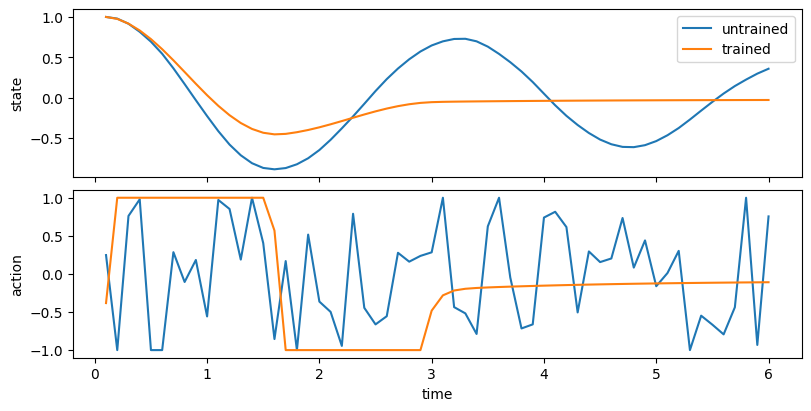

In [ ]:
after = MockSimulation(trained.path, spec).run(root / "run_trained", deterministic=True)

plot_run([before, after], ["untrained", "trained"])

## 10. Rewards from solver output

Training used a reward over `observation` and `action`, which works only because the
policy observes the whole state. A CFD case reads drag and lift from a `forceCoeffs`
functionObject instead: a second file, sampled at the CFD time step rather than at
the control step. `MockSimulation` logs the oscillator energy the same way.

In [ ]:
energy = rl.read_function_object(root / "run_trained", "energy")

print(f"{energy.sizes['time']} CFD samples for {after.sizes['time']} control steps")

`align_to_control(how="mean")` averages over the interval ending at each control
instant. `"last"` and `"interp"` cover the cases where that is not what the reward
wants.

In [ ]:
aligned = rl.align_to_control(energy, after["time"].values, how="mean")

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
window = energy["time"].values <= 2.0

ax.plot(energy["time"].values[window], energy["E"].values[window],
        color="tab:gray", linewidth=1, label="every CFD step")

keep = aligned["time"].values <= 2.0
ax.plot(aligned["time"].values[keep], aligned["E"].values[keep],
        color="k", linewidth=1.5, marker="o", markersize=5,
        drawstyle="steps-post", label="averaged onto control steps")

ax.set_xlabel("time")
ax.set_ylabel("energy")
ax.legend(frameon=False, fontsize=9)

plt.show()

`attach` joins the aligned series onto the trajectory; the reward itself is user code
over an `xr.Dataset`. In the runner this is the `function_objects=["energy"]`
argument, which reads, aligns and attaches on every episode.

In [ ]:
data = rl.attach(after, aligned)


def energy_reward(ds):
    return -rl.moving_average(ds["E"], 5)


rewards = rl.evaluate_reward(data, energy_reward)

print("available to the reward:", sorted(data.data_vars))
print(f"return over the episode: {rewards.sum():.2f}")

## 11. The Case Dictionary

What the solver reads to find the policy and build the observation. The block goes wherever the compiled controller expects it, a boundary condition or an fvOptions entry.

In [ ]:
print(rl.render_controller(spec, trained.path, name="uqtopusController", seed=42))

uqtopusController
{
    type            onnxPolicy;
    policy          experiments/rl_onnx_demo/policy_trained.onnx;
    specHash        "15f22c63b454abf1";
    contractVersion "1.0";
    controlInterval 0.1;
    startTime       0;
    seed            42;
    observation
    {
        stack           1;
        dim             2;
        sources
        (
            {
                kind            probe;
                fieldName       p;
                positions
                (
                    (0.5 0 0.005)
                    (1 0 0.005)
                );
                name            probes;
            }
        );
    }
    action
    {
        name            Q;
        nComponents     1;
        distribution    gaussian;
        rampFraction    0;
        low             (-1);
        high            (1);
        targets
        (
            {
                name            jet1;
                coefficient     1;
            }
            {
                name 